<a href="https://colab.research.google.com/github/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar/blob/main/entornos_complejos/src/taxi_SARSA.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Estudio comparativo de algoritmos en el problema Taxi-v3

*Description:* Comparación experimental de SARSA y Expected SARSA en el entorno Taxi-v3.
Se analizan recompensa promedio, longitud de episodio y estabilidad de convergencia bajo política $\epsilon$-greedy con decaimiento.

    Authors: Ginés Carrillo Ibáñez, Yago Ibarrola Lapeña, Aarón Palomar Peña
    Emails: gines.carrilloi@um.es, yago.ibarrolal@um.es, aaron.p.p@um.es
    Date: 2026/02/22


## Preparación del entorno

In [ ]:
#@title Copiar el repositorio.
print("Clonando el repositorio, tiempo estimado: 1-2 minutos...")
!git clone https://github.com/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar.git
!cd EML_Carrillo_Ibarrola_Palomar/

#@title Importamos todas las clases y funciones
import sys
# Añadir los directorio fuentes al path de Python
sys.path.append('/content/EML_Carrillo_Ibarrola_Palomar')
# Verificar que se han añadido correctamente
print(sys.path)

In [1]:
from agents import TaxiAgentSARSA, TaxiAgentExpectedSARSA
import gymnasium as gym
import numpy as np
import utils
import taxi_gif
from tqdm import tqdm

In [2]:
import random
random.seed(42)
np.random.seed(42)

## Experimento

En este experimento buscamos comparar el rendimiento, fiabilidad y rapidez de convergencia de *SARSA* y *Expected SARSA* en el entorno *Taxi-v3*, ya descrito en notebooks anteriores.

Para lograr este objetivo, realizaremos las siguientes pruebas y visualizaciones para cada método:
- Ajuste de hiperparámetros de learning rate y número de episodios.
- Heatmap de recompensa media, porcentaje de éxito y desviación estándar para distintos valores de los parámetros.
- Comparación de tiempos por episodio de entrenamiento
- Gráfica de recompensas, longitud de episodio y error diferencial
- Visualización del agente en distintas etapas del entrenamiento


## Experimento 1: SARSA

Definimos la función con la que se entrenarán los agentes mediante SARSA. Durante cada episodio siguen el siguiente bucle:
- Del estado actual $S$, toma la acción preferida $A$, que le lleva a un estado $S'$. Almacena la recompensa obtenida $R$.
- De ahí, elige (sin tomarla) la siguiente acción preferida $A'$.
- Actualiza su tabla Q con $S, A, R, S'$ y $A'$.
- $S \coloneqq S'$ y $A \coloneqq A'$

In [3]:
def train_agent_SARSA(agent, n_episodes, saving=False):
    saved_episodes = []
    n_save = 10
    
    def save_episode(episode_num):
        return episode_num % (n_episodes // n_save) == 0
    
    env = agent.env

    for n in tqdm(range(n_episodes)):
        # Start a new episode
        obs, info = env.reset()
        done = False
        episode_history = []

        if saving and save_episode(n):
            utils.save_state(agent=agent, obs=obs, is_exploring=False, episode_history=episode_history)

        # Play one complete episode
        if not done:
            action, is_exploring = agent.get_action(obs)                            #Choose action
        while not done:

            next_obs, reward, terminated, truncated, info = env.step(action)        #Take action

            next_action, next_is_exploring = agent.get_action(next_obs)                  #Choose next action (SARSA)
            agent.update(obs, action, reward, terminated, next_obs, next_action)    #Update Q-values

            if saving and save_episode(n):
                utils.save_state(agent=agent, obs=next_obs, is_exploring=is_exploring, episode_history=episode_history)
            # Move to next state
            done = terminated or truncated
            obs = next_obs
            action = next_action
            is_exploring = next_is_exploring

        # Reduce exploration rate (agent becomes less random over time)
        agent.decay_epsilon()
        
    if saving:
        return saved_episodes

### Ajuste de hiperparámetros

Empezamos realizando un ajuste de los parámetros de *learning rate* y *número de episodios*. La intención detrás de este experimento es comprobar cómo de rápido converge la política entrenada con SARSA a una óptima, para los mejores valores del learning rate.

Para esto, trabajaremos con la siguiente parrilla de valores, con la que graficaremos varios heatmaps (usamos tantos valores para generar una buena visualización, claramente esto no es necesario para obtener una combinacion de parámetros más que aceptable):

*Learning rate*

Se mueve entre $0.04$ y $0.5$, en pasos de $0.02$. Tenemos así 24 valores a probar.

*Número de episodios*

Se mueven entre $1000$ y $8000$, en incrementos de $500$. Es decir, 15 valores.

Cabe resaltar que fijamos la tasa de decaimiento de epsilon de tal forma que alcance el valor mínimo exactamente cuando lleva la proporción del entrenamiento indicada por `ratio` (si `ratio` vale $0.75$, se alcanzará `epsilon_min` cuando haya completado un $75%$ de este). Esto sucederá tanto si hablamos de decaimiento lineal como inversamente proporcional. Por lo tanto, el valor de la variable `epsilon_decay` también cambia con el número de episodios.

In [4]:
def grid_search_SARSA(learning_rates, n_episodes_list):
    best_avg_reward = float('-inf')
    best_params = None

    win_rates = np.zeros((len(learning_rates), len(n_episodes_list)))
    avg_rewards = np.zeros((len(learning_rates), len(n_episodes_list)))
    std_rewards = np.zeros((len(learning_rates), len(n_episodes_list)))

    for i, lr in enumerate(learning_rates):
        for j, n_eps in enumerate(n_episodes_list):
            print(f"Testing learning_rate={lr}, n_episodes={n_eps}")

            # Create environment and agent
            env = gym.make("Taxi-v3")
            env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_eps)

            initial_epsilon = 1.0
            final_epsilon = 0.1
            ratio = 0.5 # Fraccion del entrenamiento previo al epsilon minimo

            agent = TaxiAgentSARSA(
                env=env,
                learning_rate=lr,
                initial_epsilon=initial_epsilon,
                epsilon_decay= (initial_epsilon - final_epsilon)/(n_eps * ratio), #(initial_epsilon / final_epsilon - 1)/(n_eps * ratio),
                final_epsilon=final_epsilon,
                decay_type="linear"
            )
            train_agent_SARSA(agent, n_eps, saving=False)
            win_rates[i, j], avg_rewards[i, j], std_rewards[i, j] = agent.test()
            print(f"Average Reward: {avg_rewards[i, j]}")

            if avg_rewards[i, j] > best_avg_reward:
                best_avg_reward = avg_rewards[i, j]
                best_params = (lr, n_eps)

    print(f"Best Params: learning_rate={best_params[0]}, n_episodes={best_params[1]} with Average Reward={best_avg_reward}")
    return win_rates, avg_rewards, std_rewards, best_params

In [5]:

lr_step = 0.02
learning_rates = np.arange(0.04, 0.5 + lr_step, lr_step)
n_eps_step = 500
n_episodes_list = range(1000, 8000 + n_eps_step, n_eps_step)
win_rates, avg_rewards, std_rewards, best_params = grid_search_SARSA(learning_rates=learning_rates, n_episodes_list=n_episodes_list)


Testing learning_rate=0.04, n_episodes=1000


100%|██████████| 1000/1000 [00:03<00:00, 299.24it/s]


Test Results over 1000 episodes:
Win Rate: 4.8%
Average Reward: -195.194
Standard Deviation: 108.936
Average Reward: -195.194
Testing learning_rate=0.04, n_episodes=1500


100%|██████████| 1500/1500 [00:04<00:00, 363.50it/s]


Test Results over 1000 episodes:
Win Rate: 12.7%
Average Reward: -173.058
Standard Deviation: 70.640
Average Reward: -173.058
Testing learning_rate=0.04, n_episodes=2000


...

Test Results over 1000 episodes:
Win Rate: 54.4%
Average Reward: -162.199
Standard Deviation: 395.233
Average Reward: -162.199
Testing learning_rate=0.4999999999999999, n_episodes=7500


100%|██████████| 7500/7500 [00:09<00:00, 812.92it/s] 


Test Results over 1000 episodes:
Win Rate: 82.7%
Average Reward: -207.473
Standard Deviation: 590.439
Average Reward: -207.473
Testing learning_rate=0.4999999999999999, n_episodes=8000


100%|██████████| 8000/8000 [00:09<00:00, 825.49it/s] 


Test Results over 1000 episodes:
Win Rate: 67.9%
Average Reward: -56.801
Standard Deviation: 96.017
Average Reward: -56.801
Best Params: learning_rate=0.15999999999999998, n_episodes=6500 with Average Reward=7.926


Una vez realizada la búsqueda, mostramos los siguientes heatmaps, con los datos obtenidos usando la función test con 1000 episodios sobre cada agente:

- Recompensa media obtenida en los 1000 episodios
- Tasa de éxito (definiendo éxito como recompensa total de episodio mayor que 0).
- Desviación típica de las recompensas (el máximo entre esta y 100, para apreciar diferencias entre valores bajos).

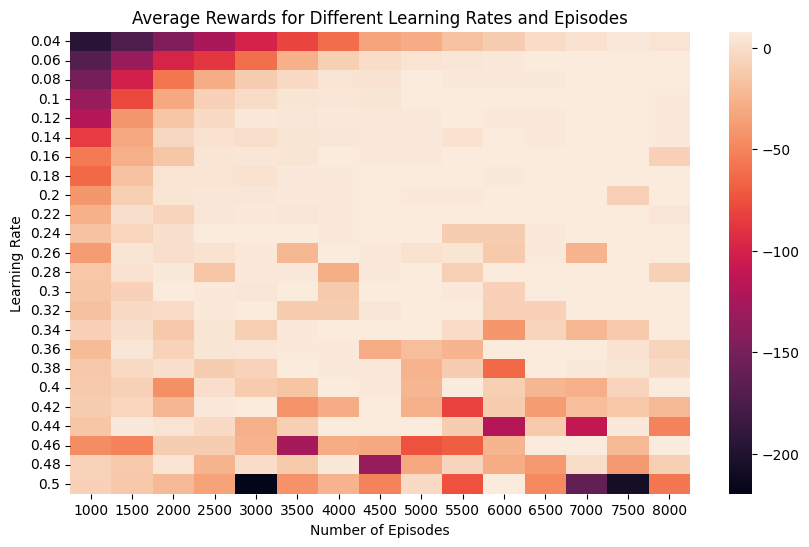

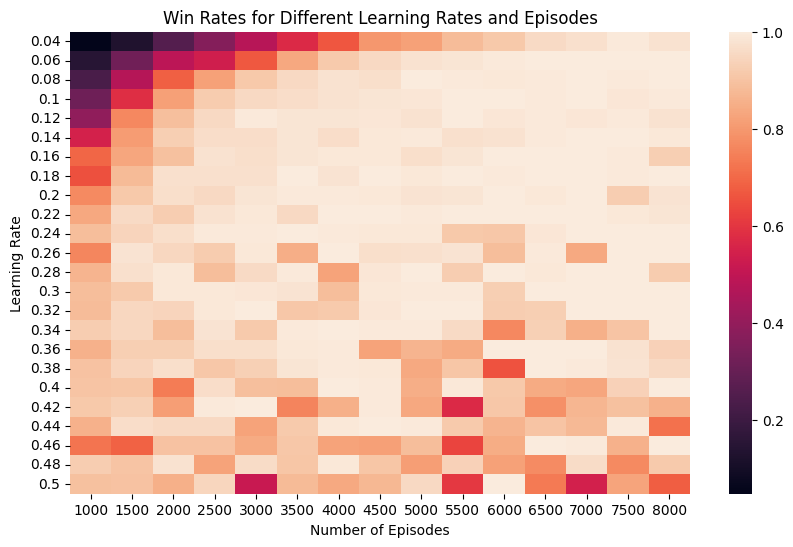

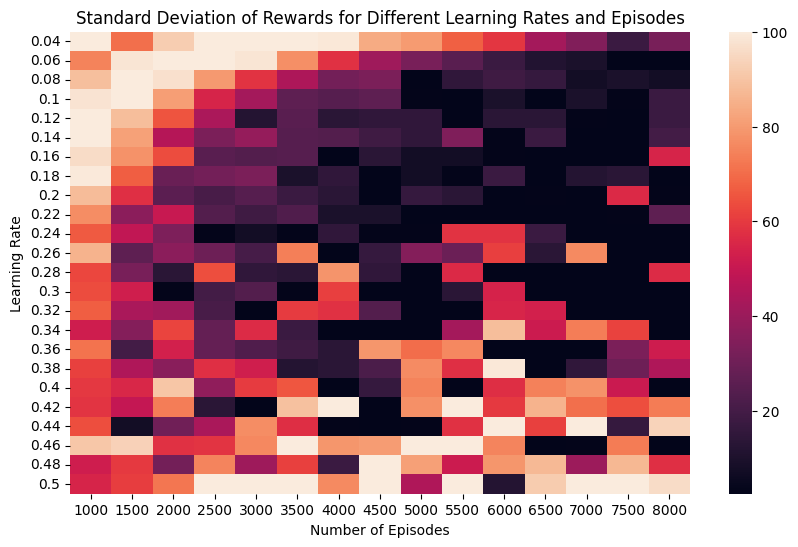

In [6]:
#heatmap of results
import matplotlib.pyplot as plt
import seaborn as sns

learning_rates = [round(n, 3) for n in learning_rates]  # Convert to integers for better display

# Create a heatmap of average rewards
plt.figure(figsize=(10, 6))
sns.heatmap(avg_rewards, annot=False, fmt=".2f", xticklabels=n_episodes_list, yticklabels=learning_rates)
plt.title("Average Rewards for Different Learning Rates and Episodes")
plt.xlabel("Number of Episodes")
plt.ylabel("Learning Rate")
plt.show()

# Create a heatmap of win rates
plt.figure(figsize=(10, 6))
sns.heatmap(win_rates, annot=False, fmt=".2f", xticklabels=n_episodes_list, yticklabels=learning_rates)
plt.title("Win Rates for Different Learning Rates and Episodes")
plt.xlabel("Number of Episodes")
plt.ylabel("Learning Rate")
plt.show()

# Create a heatmap of standard deviation of rewards
plt.figure(figsize=(10, 6))
#sns.heatmap(np.log(std_rewards + 1e-8), annot=False, fmt=".2f", xticklabels=n_episodes_list, yticklabels=learning_rates)
sns.heatmap(np.minimum(std_rewards, 100), annot=False, fmt=".2f", xticklabels=n_episodes_list, yticklabels=learning_rates)
plt.title("Standard Deviation of Rewards for Different Learning Rates and Episodes")
plt.xlabel("Number of Episodes")
plt.ylabel("Learning Rate")
plt.show()

Comentarios cuando se haya generado!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Comentar tambien consass sobre tiempos necesarios para entrenamiento con cada metodo.

Elegimos una combinación de parámetros de entre aquellas que alcanzan la política óptima, del centro aproximado de la región en la que la desviación tipica es baja, para asegurarnos de convergencia a la política óptima.

Entrenamos de nuevo un agente con estas características

  0%|          | 0/7500 [00:00<?, ?it/s]

100%|██████████| 7500/7500 [00:09<00:00, 792.93it/s] 


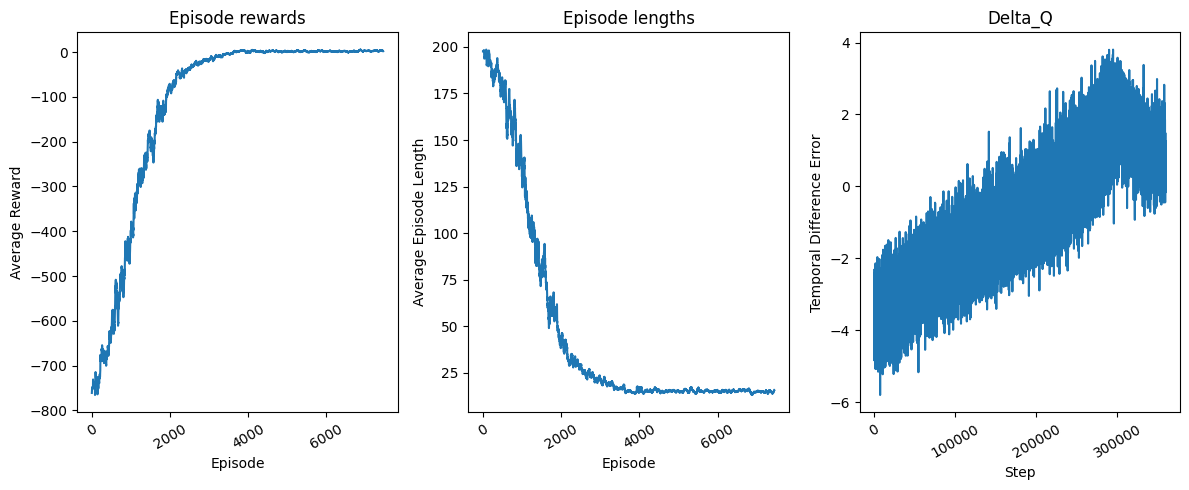

In [ ]:
learning_rate, n_episodes = (0.24, 7500) 

env = gym.make("Taxi-v3")
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)
initial_epsilon = 1.0
final_epsilon = 0.1
ratio = 0.5 # Fraccion del entrenamiento previo al epsilon minimo

agent = TaxiAgentSARSA(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=initial_epsilon,
    epsilon_decay=(initial_epsilon - final_epsilon )/(n_episodes * ratio),
    final_epsilon=final_epsilon,
    decay_type="linear"
)

saved_episodes = train_agent_SARSA(agent, n_episodes, saving=True)

utils.plot_training_metrics(env.return_queue, env.length_queue, agent.training_error, rolling_length=50)
utils.save_training_metrics(env.return_queue, env.length_queue, agent.training_error, filename="../data/results/SARSA/SARSA_metrics")

In [29]:
agent.test()

Test Results over 1000 episodes:
Win Rate: 98.5%
Average Reward: 5.861
Standard Deviation: 19.816


(np.float64(0.985), np.float64(5.861), np.float64(19.816146926181183))

En las gráficas...!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [ ]:
print("Sample episodes (every 10% of training):")
n_save = 10
for i, episode_history in enumerate(saved_episodes):
    print(f"Episode {i * (n_episodes // n_save)}")
    taxi_gif.animar_estados_taxi_gif(episode_history=episode_history, nombre_archivo=f"../data/gifs_taxi/SARSA/episode_{i * (n_episodes // n_save)}.gif", fps=2)

Sample episodes (every 10% of training):


## Experimento 2: Expected SARSA

In [10]:
def train_agent_expected_SARSA(agent, n_episodes, saving=False):
    saved_episodes = []
    n_save = 10
    
    def save_episode(episode_num):
        return episode_num % (n_episodes // n_save) == 0
    
    env = agent.env

    for n in tqdm(range(n_episodes)):
        # Start a new episode
        obs, info = env.reset()
        done = False
        episode_history = []

        if saving and save_episode(n):
            utils.save_state(agent=agent, obs=obs, is_exploring=False, episode_history=episode_history)
            
        while not done:
            # Agent chooses action (initially random, gradually more intelligent)
            action, is_exploring = agent.get_action(obs)

            # Take action and observe result
            next_obs, reward, terminated, truncated, info = env.step(action)

            # Learn from this experience
            agent.update(obs, action, reward, terminated, next_obs)

            # Move to next state
            done = terminated or truncated
            obs = next_obs

            # Save move history
            if saving and save_episode(n):
                utils.save_state(agent=agent, obs=obs, is_exploring=is_exploring, episode_history=episode_history)
    
        if saving and save_episode(n):
            saved_episodes.append(episode_history)

        # Reduce exploration rate (agent becomes less random over time)
        agent.decay_epsilon()
        
    if saving:
        return saved_episodes

In [ ]:
def grid_search_expected_SARSA(learning_rates, n_episodes_list):
    best_avg_reward = float('-inf')
    best_params = None

    win_rates = np.zeros((len(learning_rates), len(n_episodes_list)))
    avg_rewards = np.zeros((len(learning_rates), len(n_episodes_list)))
    std_rewards = np.zeros((len(learning_rates), len(n_episodes_list)))

    for i, lr in enumerate(learning_rates):
        for j, n_eps in enumerate(n_episodes_list):
            print(f"Testing learning_rate={lr}, n_episodes={n_eps}")

            # Create environment and agent
            env = gym.make("Taxi-v3")
            env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_eps)
            
            initial_epsilon = 1.0
            final_epsilon = 0.1
            ratio = 0.5 # Fraccion del entrenamiento previo al epsilon minimo

            agent = TaxiAgentExpectedSARSA(
                env=env,
                learning_rate=lr,
                initial_epsilon=initial_epsilon,
                epsilon_decay=(initial_epsilon - final_epsilon)/(n_eps * ratio),
                final_epsilon=final_epsilon,
                decay_type="linear"
            )
            train_agent_expected_SARSA(agent, n_eps, saving=False)
            win_rates[i, j], avg_rewards[i, j], std_rewards[i, j] = agent.test()
            print(f"Average Reward: {avg_rewards[i, j]}")

            if avg_rewards[i, j] > best_avg_reward:
                best_avg_reward = avg_rewards[i, j]
                best_params = (lr, n_eps)

    print(f"Best Params: learning_rate={best_params[0]}, n_episodes={best_params[1]} with Average Reward={best_avg_reward}")
    return win_rates, avg_rewards, std_rewards, best_params


In [12]:
lr_step = 0.02
learning_rates = np.arange(0.04, 0.5 + lr_step, lr_step)
n_eps_step = 500
n_episodes_list = range(1000, 8000 + n_eps_step, n_eps_step)
win_rates, avg_rewards, std_rewards, best_params = grid_search_SARSA(learning_rates=learning_rates, n_episodes_list=n_episodes_list)

Testing learning_rate=0.04, n_episodes=1000


100%|██████████| 1000/1000 [00:03<00:00, 297.02it/s]


Test Results over 1000 episodes:
Win Rate: 4.9%
Average Reward: -193.162
Standard Deviation: 93.043
Average Reward: -193.162
Testing learning_rate=0.04, n_episodes=1500


100%|██████████| 1500/1500 [00:04<00:00, 351.05it/s]


Test Results over 1000 episodes:
Win Rate: 15.1%
Average Reward: -168.146
Standard Deviation: 75.536
Average Reward: -168.146
Testing learning_rate=0.04, n_episodes=2000


...

Test Results over 1000 episodes:
Win Rate: 90.1%
Average Reward: -84.055
Standard Deviation: 391.283
Average Reward: -84.055
Testing learning_rate=0.4999999999999999, n_episodes=7500


100%|██████████| 7500/7500 [00:08<00:00, 837.58it/s] 


Test Results over 1000 episodes:
Win Rate: 82.8%
Average Reward: -28.019
Standard Deviation: 78.428
Average Reward: -28.019
Testing learning_rate=0.4999999999999999, n_episodes=8000


100%|██████████| 8000/8000 [00:09<00:00, 840.84it/s] 


Test Results over 1000 episodes:
Win Rate: 97.3%
Average Reward: 2.062
Standard Deviation: 33.784
Average Reward: 2.062
Best Params: learning_rate=0.25999999999999995, n_episodes=7500 with Average Reward=8.011


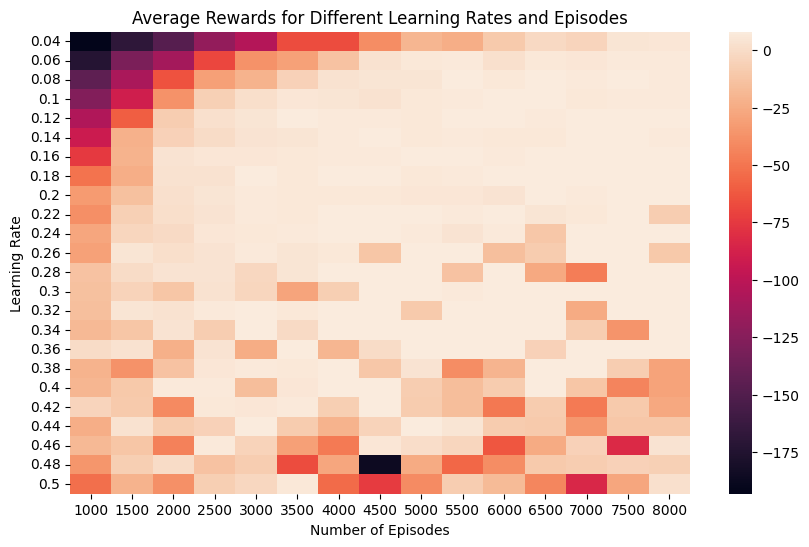

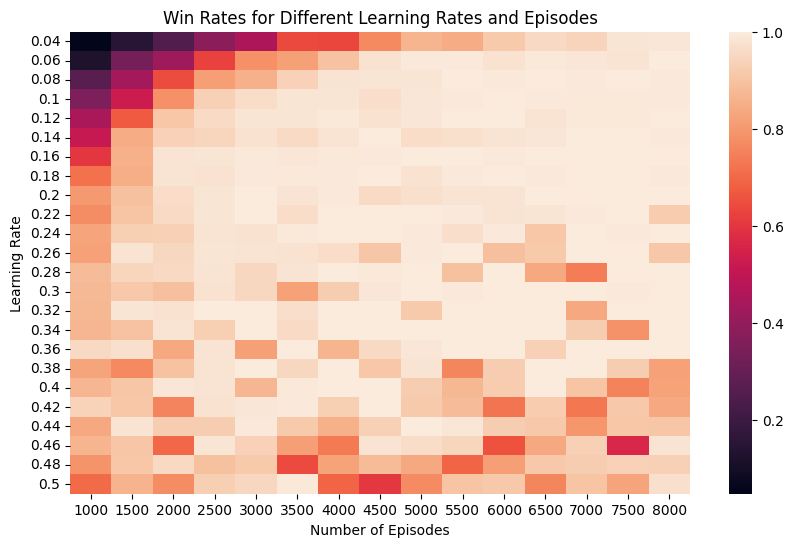

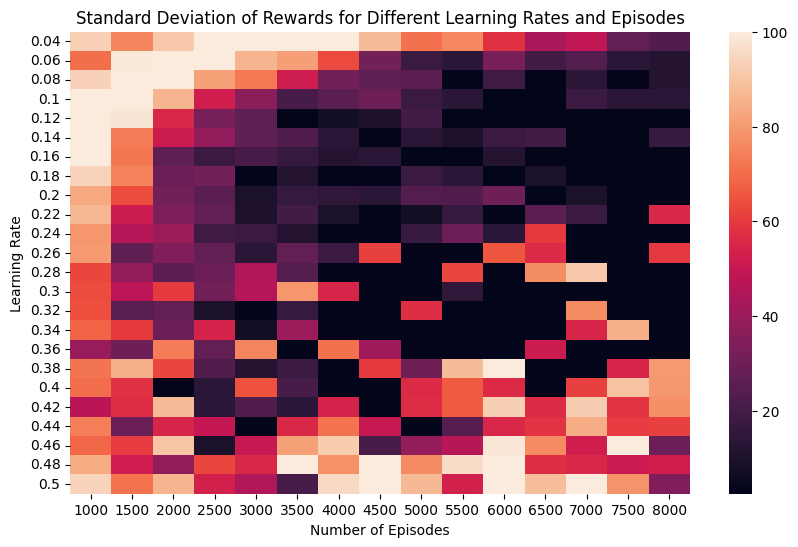

In [13]:
#heatmap of results
import matplotlib.pyplot as plt
import seaborn as sns

learning_rates = [round(n, 3) for n in learning_rates]  # Convert to integers for better display

# Create a heatmap of average rewards
plt.figure(figsize=(10, 6))
sns.heatmap(avg_rewards, annot=False, fmt=".2f", xticklabels=n_episodes_list, yticklabels=learning_rates)
plt.title("Average Rewards for Different Learning Rates and Episodes")
plt.xlabel("Number of Episodes")
plt.ylabel("Learning Rate")
plt.show()

# Create a heatmap of win rates
plt.figure(figsize=(10, 6))
sns.heatmap(win_rates, annot=False, fmt=".2f", xticklabels=n_episodes_list, yticklabels=learning_rates)
plt.title("Win Rates for Different Learning Rates and Episodes")
plt.xlabel("Number of Episodes")
plt.ylabel("Learning Rate")
plt.show()

# Create a heatmap of standard deviation of rewards
plt.figure(figsize=(10, 6))
#sns.heatmap(np.log(std_rewards + 1e-8), annot=False, fmt=".2f", xticklabels=n_episodes_list, yticklabels=learning_rates)
sns.heatmap(np.minimum(std_rewards, 100), annot=False, fmt=".2f", xticklabels=n_episodes_list, yticklabels=learning_rates)
plt.title("Standard Deviation of Rewards for Different Learning Rates and Episodes")
plt.xlabel("Number of Episodes")
plt.ylabel("Learning Rate")
plt.show()

  0%|          | 0/4000 [00:00<?, ?it/s]

100%|██████████| 4000/4000 [00:03<00:00, 1117.44it/s]


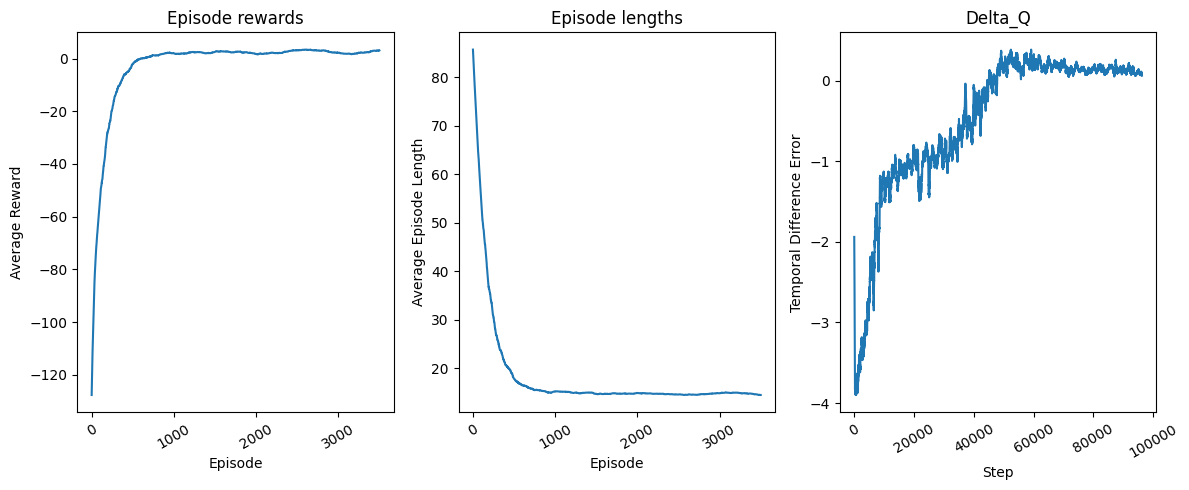

Test Results over 1000 episodes:
Win Rate: 100.0%
Average Reward: 8.003
Standard Deviation: 2.602


(np.float64(1.0), np.float64(8.003), np.float64(2.6021127954029977))

In [ ]:
learning_rate, n_episodes = (0.24, 4000) 

ratio = 0.95 # Fraccion del entrenamiento previo al epsilon minimo
initial_epsilon = 1.0
final_epsilon = 0.1

env = gym.make("Taxi-v3")
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)
agent = TaxiAgentExpectedSARSA(
                env=env,
                learning_rate=learning_rate,
                initial_epsilon=initial_epsilon,
                epsilon_decay = (initial_epsilon / final_epsilon - 1)/(n_episodes * ratio),
                final_epsilon=final_epsilon,
                decay_type="inverse"
            )

saved_episodes = train_agent_expected_SARSA(agent, n_episodes, saving=True)

utils.plot_training_metrics(env.return_queue, env.length_queue, agent.training_error, rolling_length=500)
utils.save_training_metrics(env.return_queue, env.length_queue, agent.training_error, filename="../data/results/ExpectedSARSA/ExpectedSARSA_inverse_metrics")
agent.test()

  0%|          | 0/4000 [00:00<?, ?it/s]

100%|██████████| 4000/4000 [00:07<00:00, 532.03it/s] 


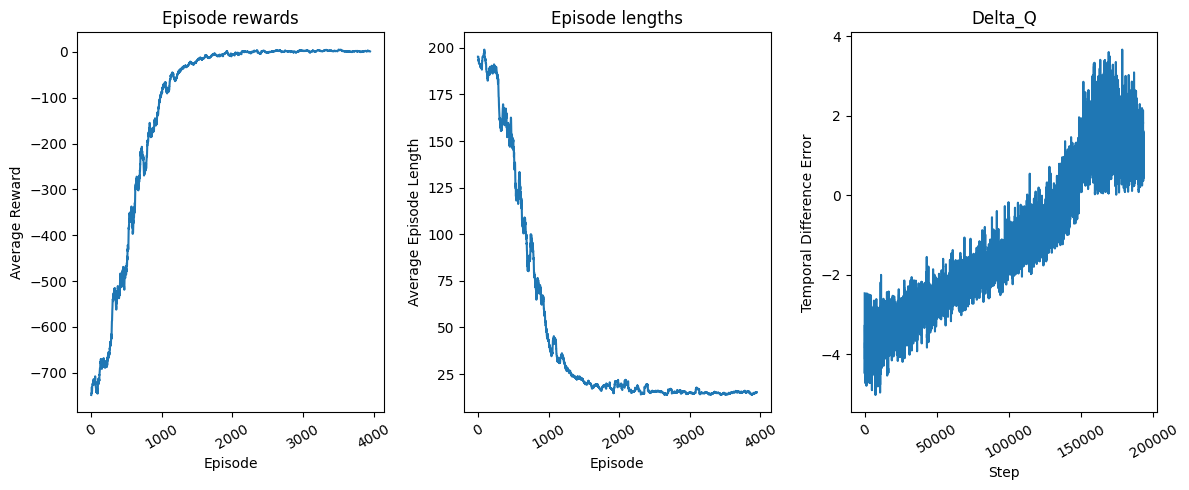

Test Results over 1000 episodes:
Win Rate: 100.0%
Average Reward: 7.883
Standard Deviation: 2.629


(np.float64(1.0), np.float64(7.883), np.float64(2.6289372377445606))

In [ ]:
learning_rate, n_episodes = (0.24, 4000) 

initial_epsilon = 1.0
final_epsilon = 0.1
ratio = 0.5

env = gym.make("Taxi-v3")
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)
agent = TaxiAgentExpectedSARSA(
                env=env,
                learning_rate=learning_rate,
                initial_epsilon=initial_epsilon,
                epsilon_decay=(initial_epsilon - final_epsilon) / (n_episodes * ratio),
                final_epsilon=final_epsilon,
                decay_type="linear"
            )

saved_episodes = train_agent_expected_SARSA(agent, n_episodes, saving=True)

utils.plot_training_metrics(env.return_queue, env.length_queue, agent.training_error, rolling_length=50)
utils.save_training_metrics(env.return_queue, env.length_queue, agent.training_error, filename="../data/results/ExpectedSARSA/ExpectedSARSA_metrics")
agent.test()